In [23]:
import stlrom
from stlrom import Signal, SignalGen, OscillSignalGen, PWCSignalGen
import matplotlib.pyplot as plt
import numpy as np
import os

step_gen = PWCSignalGen()
osc_gen  = OscillSignalGen()


begin_time: 0  end_time: 5
time:          0  value:          0  derivative:      6.267
time:       0.02  value:     0.1253  derivative:      6.168
time:       0.04  value:     0.2487  derivative:      5.972
time:       0.06  value:     0.3681  derivative:      5.681
time:       0.08  value:     0.4818  derivative:      5.302
time:        0.1  value:     0.5878  derivative:      4.838
time:       0.12  value:     0.6845  derivative:      4.298
time:       0.14  value:     0.7705  derivative:      3.691
time:       0.16  value:     0.8443  derivative:      3.025
time:       0.18  value:     0.9048  derivative:      2.311
time:        0.2  value:     0.9511  derivative:      1.562
time:       0.22  value:     0.9823  derivative:      0.787
time:       0.24  value:      0.998  derivative:          0
time:       0.26  value:      0.998  derivative:     -0.787
time:       0.28  value:     0.9823  derivative:     -1.562
time:        0.3  value:     0.9511  derivative:     -2.311
time:       0

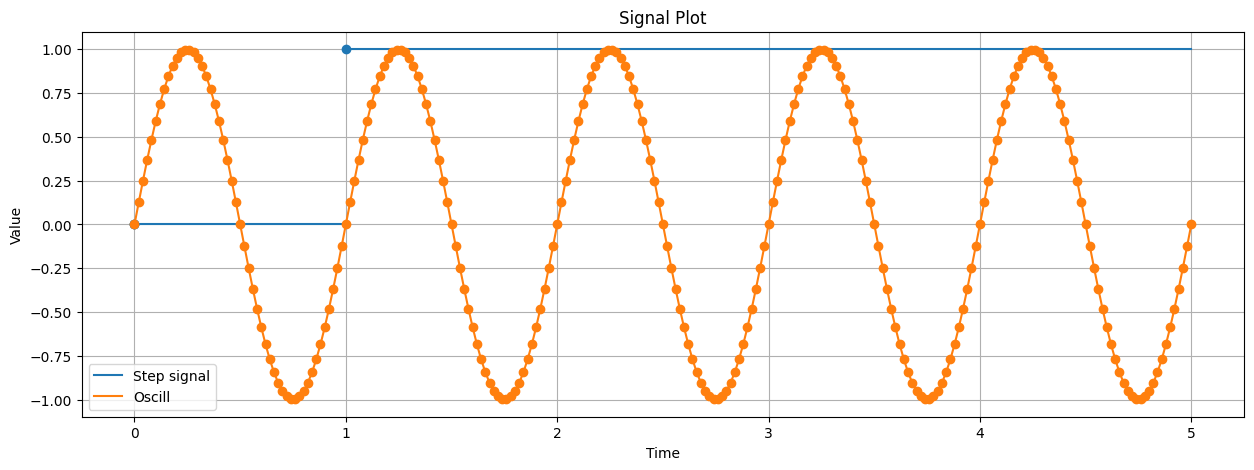

In [24]:
step_sig = step_gen.get_signal(t0=0, tf=5)
ax = step_sig.plot(label= 'Step signal')
sin_sig = osc_gen.get_signal(dt=0.02, tf=5)
sin_sig.plot(ax=ax, label='Oscill')
print(sin_sig)


In [25]:
driver = stlrom.STLDriver()
driver.parse_string('signal step, sin')
driver.parse_string('mu_step := step[t]==0')
driver.parse_string('mu_sin := sin[t]==0')
driver.parse_string('mu_and := mu_step and mu_sin')
driver.parse_string('mu_or := mu_step or mu_sin')
driver.parse_string('phi := mu_and until[0,1] mu_or')

print(driver)

# STLDriver object defined as
signal sin, step

# With formulas
mu_and:= step[t] == 0 and sin[t] == 0
mu_or:= step[t] == 0 or sin[t] == 0
mu_sin:= sin[t] == 0
mu_step:= step[t] == 0
phi:=  (step[t] == 0 and sin[t] == 0) until_[0,1] (step[t] == 0 or sin[t] == 0) 

# Data:
No data yet.


In [26]:
driver.set_signals([step_sig, sin_sig])

print(driver)

# STLDriver object defined as
signal sin, step

# With formulas
mu_and:= step[t] == 0 and sin[t] == 0
mu_or:= step[t] == 0 or sin[t] == 0
mu_sin:= sin[t] == 0
mu_step:= step[t] == 0
phi:=  (step[t] == 0 and sin[t] == 0) until_[0,1] (step[t] == 0 or sin[t] == 0) 

# Data:

# Signal sin:
251 samples from t0=0 to t_end=5

# Signal step:
3 samples from t0=0 to t_end=5



{' (step[t] == 0 and sin[t] == 0) until_[0,1] (step[t] == 0 or sin[t] == 0) ': <stlrom._stlrom.Signal object at 0x7aecfa89be30>, 'sin': <stlrom._stlrom.Signal object at 0x7aecfa898cf0>, 'sin[t] == 0': <stlrom._stlrom.Signal object at 0x7aecfa89bb30>, 'step': <stlrom._stlrom.Signal object at 0x7aecfa899430>, 'step[t] == 0': <stlrom._stlrom.Signal object at 0x7aecf8ac2670>, 'step[t] == 0 and sin[t] == 0': <stlrom._stlrom.Signal object at 0x7aecf8ac17f0>, 'step[t] == 0 or sin[t] == 0': <stlrom._stlrom.Signal object at 0x7aecfa80b470>}
{' (step[t] == 0 and sin[t] == 0) until_[0,1] (step[t] == 0 or sin[t] == 0) ': <stlrom._stlrom.Signal object at 0x7aecfa8092f0>, 'sin': <stlrom._stlrom.Signal object at 0x7aecf8ad7870>, 'sin[t] == 0': <stlrom._stlrom.Signal object at 0x7aecf8bf68f0>, 'step': <stlrom._stlrom.Signal object at 0x7aecfa840ef0>, 'step[t] == 0': <stlrom._stlrom.Signal object at 0x7aecfa8407b0>, 'step[t] == 0 and sin[t] == 0': <stlrom._stlrom.Signal object at 0x7aecfa841c30>, 'step

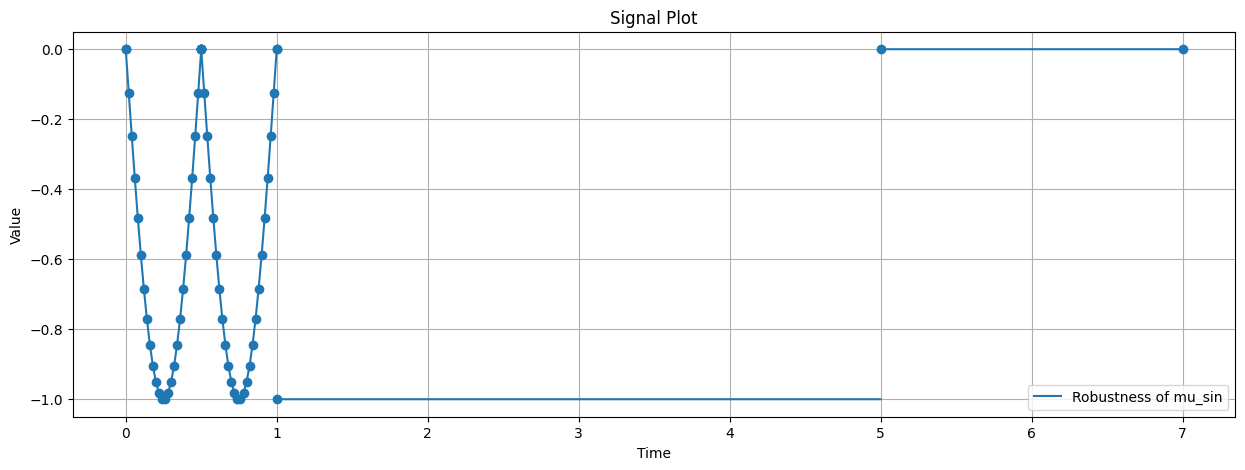

In [27]:
Signal.set_BigM(2)

mon = driver.get_monitor("phi")
rob = mon.eval_online_rob( 0, 6)
ax = rob[0].plot(label='Robustness of mu_sin')
# ax = rob[1].plot(ax=ax, label='Lower bound of robustness of mu_sin')
# ax = rob[2].plot(ax=ax, label='Upper bound of robustness of mu_sin')

monitor_rob_map = mon.get_online_robustness_map()
for rm in monitor_rob_map:
    print(rm)


sin: No samples to plot.
step: No samples to plot.
sin: No samples to plot.
step: No samples to plot.


<Axes: title={'center': 'Upper Robustness Map for phi'}, xlabel='Time', ylabel='Value'>

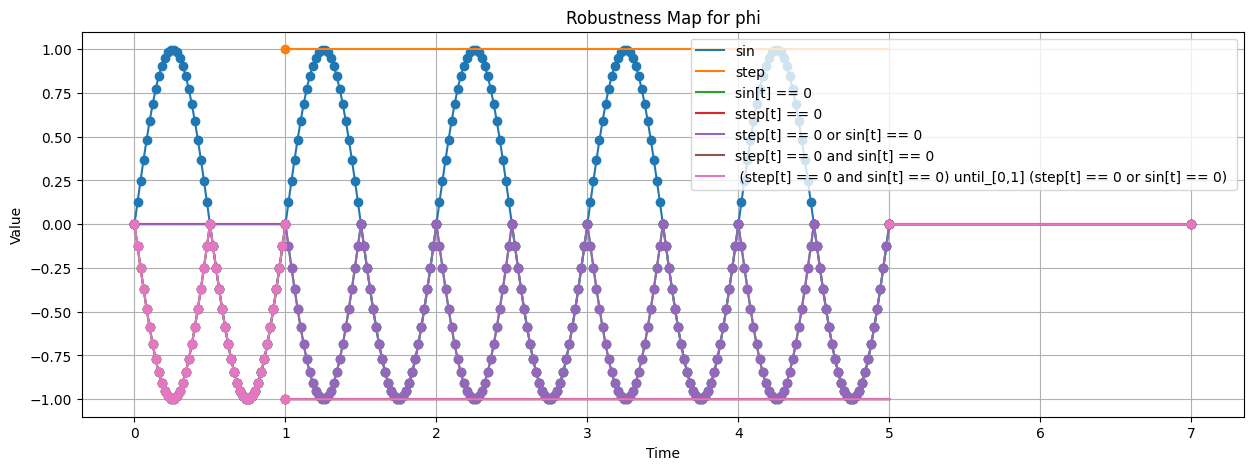

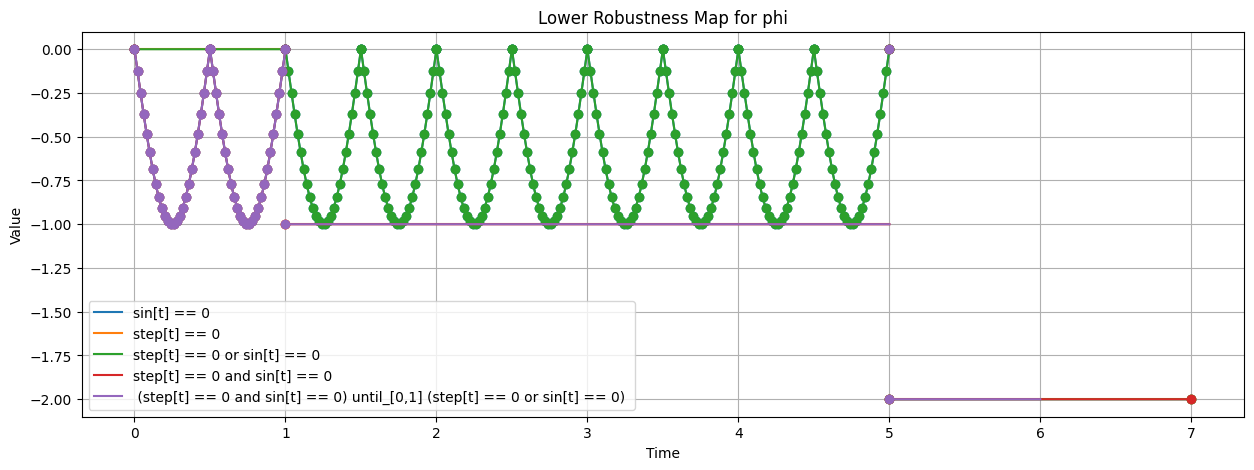

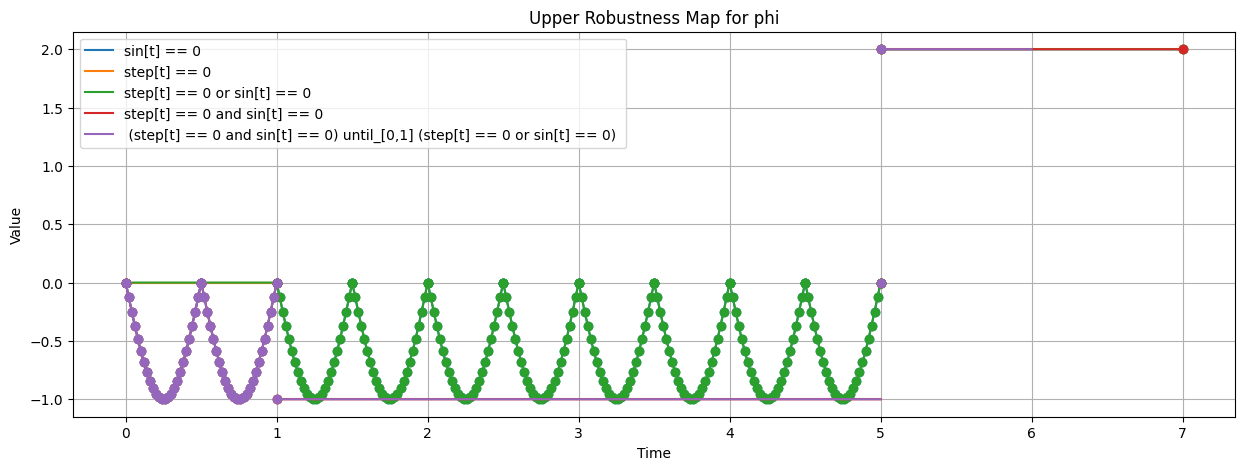

In [28]:
from stlrom import plot_rob_map
plot_rob_map(monitor_rob_map[0], same_figure=True, title='Robustness Map for phi')
plot_rob_map(monitor_rob_map[1], same_figure=True, title='Lower Robustness Map for phi')
plot_rob_map(monitor_rob_map[2], same_figure=True, title='Upper Robustness Map for phi')

{' (step[t] == 0 and sin[t] == 0) until_[0,1] (step[t] == 0 or sin[t] == 0) ': <stlrom._stlrom.Signal object at 0x7aecf8be8e70>, 'sin': <stlrom._stlrom.Signal object at 0x7aecf8ea3af0>, 'sin[t] == 0': <stlrom._stlrom.Signal object at 0x7aecf8eb1af0>, 'step': <stlrom._stlrom.Signal object at 0x7aecfad58eb0>, 'step[t] == 0': <stlrom._stlrom.Signal object at 0x7aecf8e80ff0>, 'step[t] == 0 and sin[t] == 0': <stlrom._stlrom.Signal object at 0x7aecfa7fedb0>, 'step[t] == 0 or sin[t] == 0': <stlrom._stlrom.Signal object at 0x7aecfa7ff3f0>}


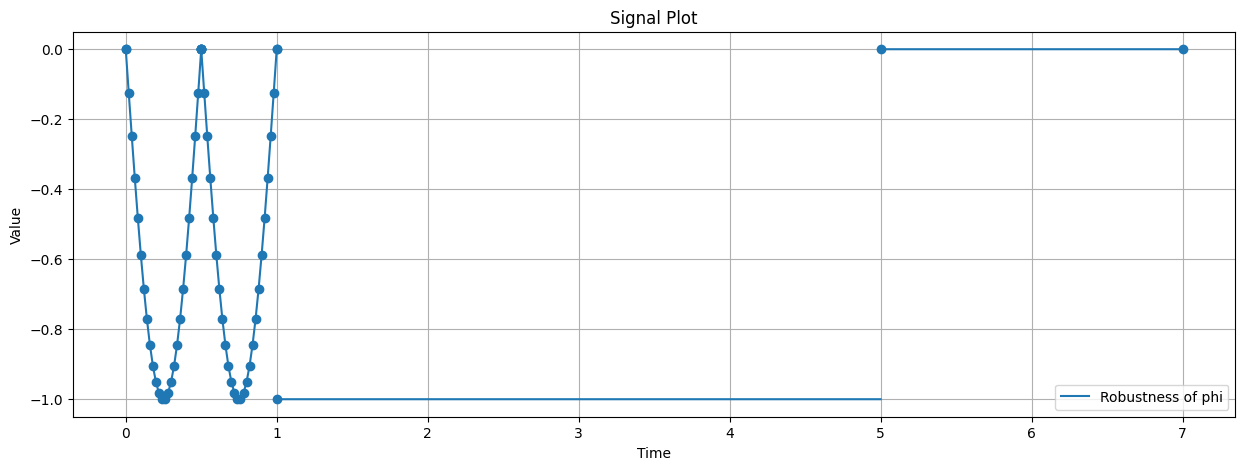

In [29]:
z = driver.eval_rob("phi", 0, 6)
z.plot(label='Robustness of phi')

rob_map = driver.get_robustness_map("phi")
print(rob_map)

<Axes: title={'center': 'Robustness Map'}, xlabel='Time', ylabel='Value'>

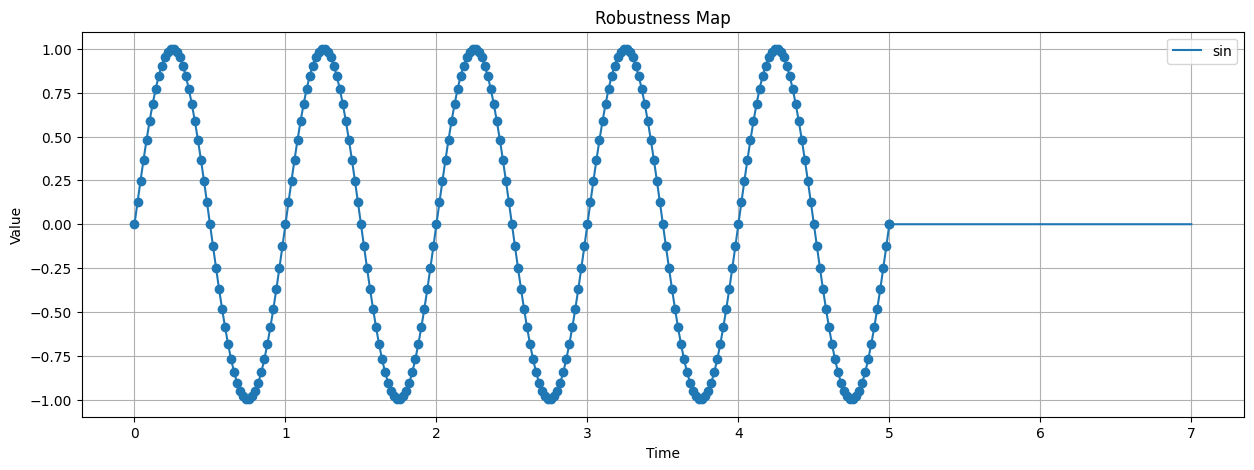

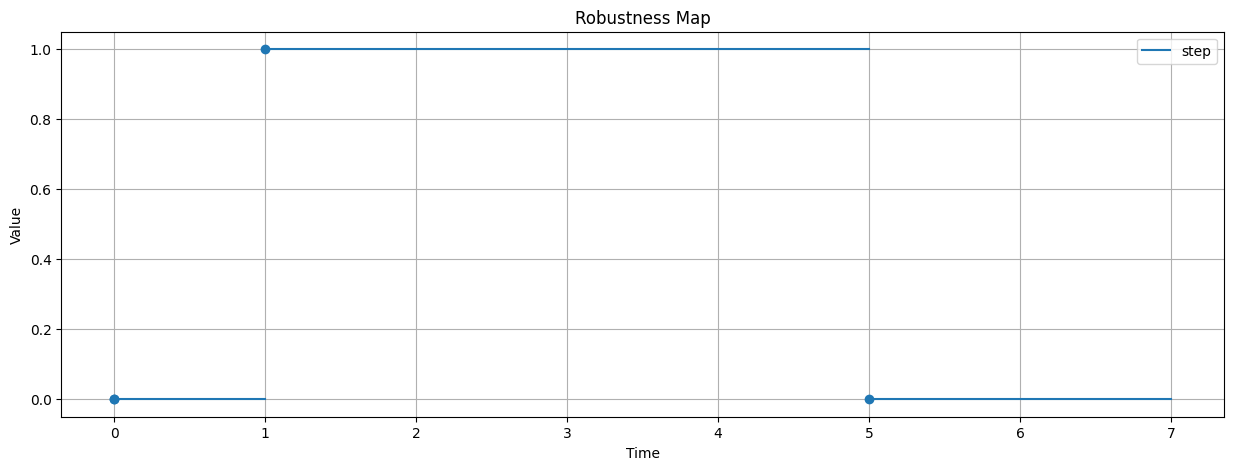

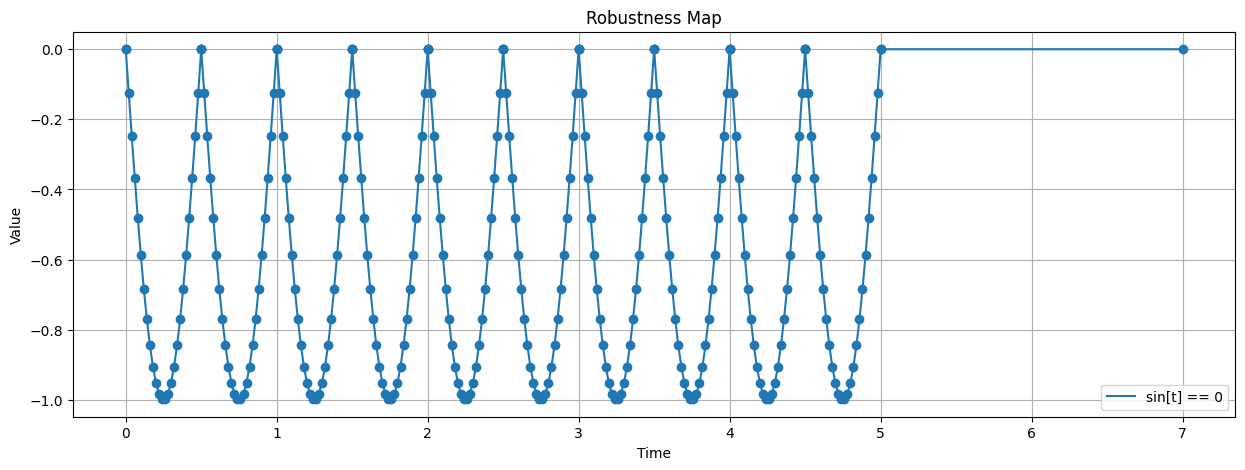

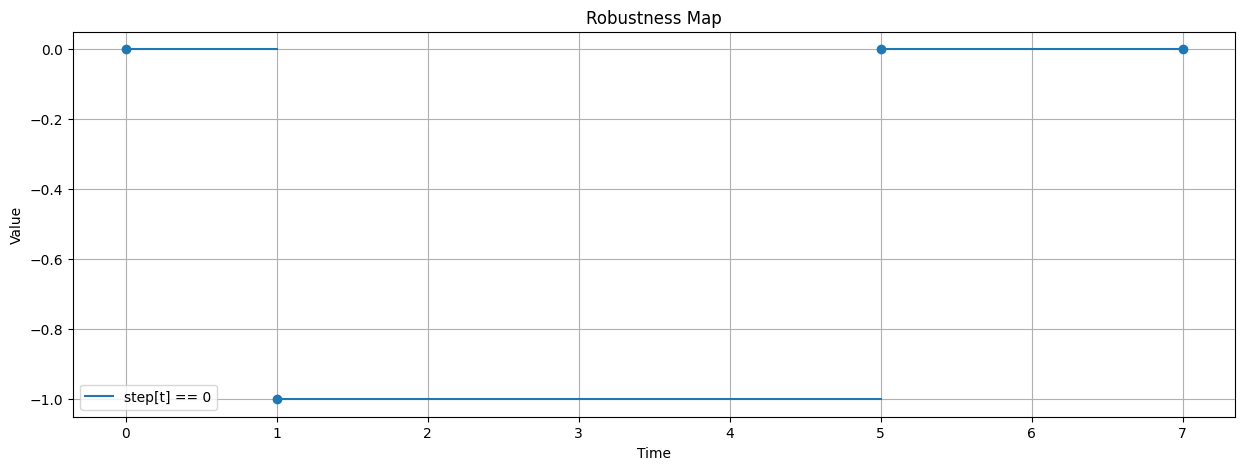

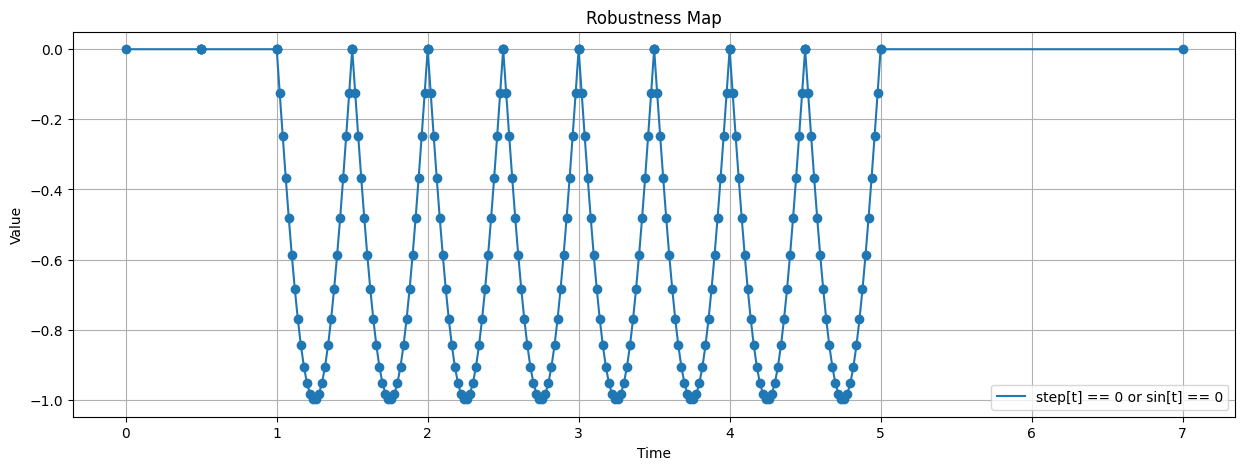

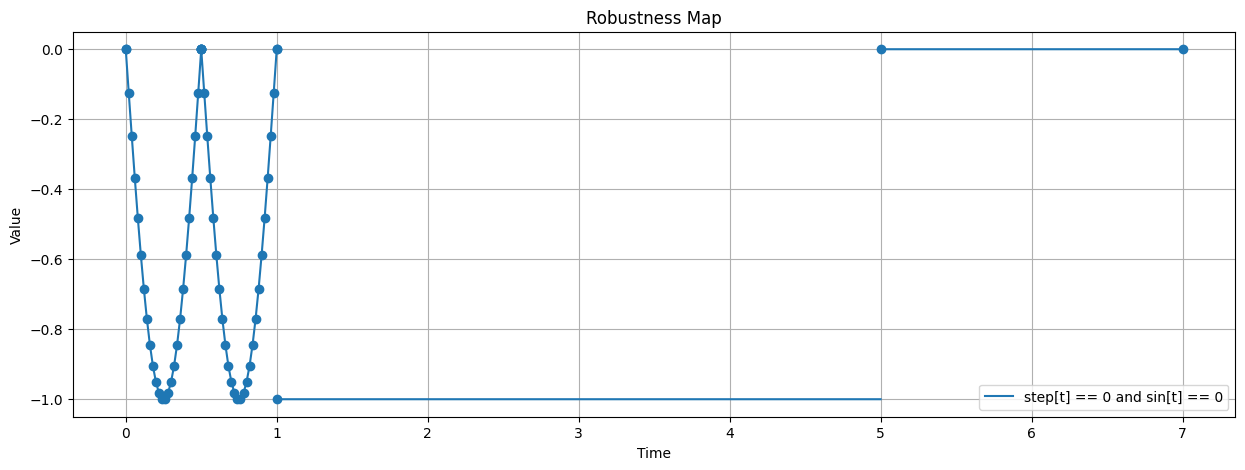

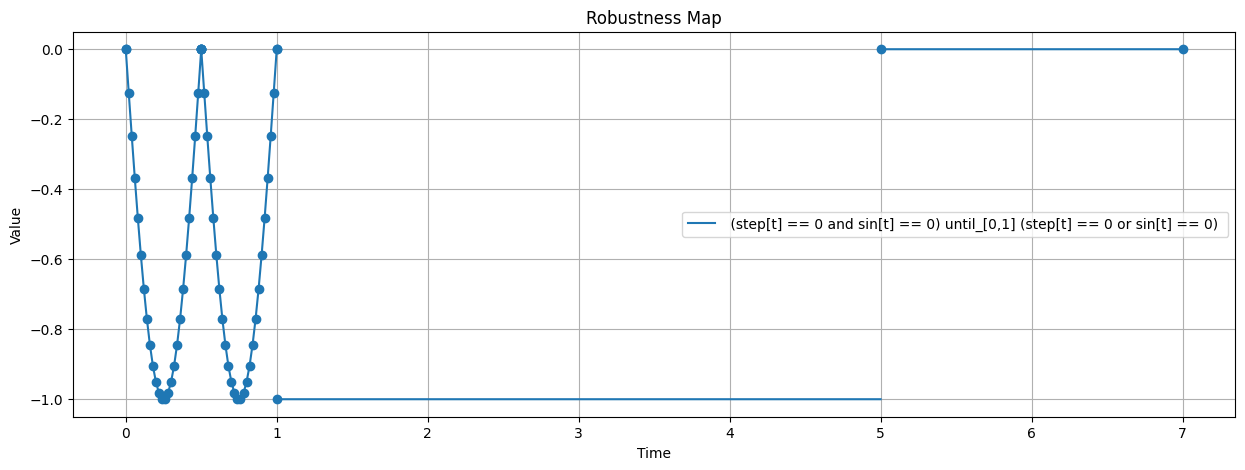

In [30]:
plot_rob_map(rob_map, same_figure=False)

In [31]:
from stlrom import plot_rob_map_widget

plot_rob_map_widget(rob_map)

interactive(children=(Dropdown(description='Subformula:', layout=Layout(width='43.0em'), options=(' (step[t] =…

In [ ]:
z_mon_mu_sin = driver.get_monitor("mu_sin").eval_rob(0, 6)
z_mon_mu_sin.plot(label='Robustness of mu_sin')

print(z_mon_mu_sin)

In [ ]:
# testing writing and loading csv
directory = 'test_signals'
os.makedirs(directory, exist_ok=True)
driver.write_csv(directory)


In [ ]:


driver2 = stlrom.STLDriver()
driver2.parse_string('signal step, sin')
driver2.parse_string('mu_step := step[t]==0')
driver2.parse_string('mu_sin := sin[t]==0')

# this has to be in order of signals in the STLDriver
driver2.load_csv([f'{directory}/step.csv', f'{directory}/sin.csv'])

driver2.get_rob('mu_step', 0)

ax2 = driver2.data[0].plot(label='Step signal from csv')
driver2.data[1].plot(ax=ax2, label='Oscill signal from csv')